In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

df = pd.read_csv("processed_caltech.csv")

In [3]:
df['connectionTime'] = pd.to_datetime(df['connectionTime'])

df['hour'] = df['connectionTime'].dt.hour
df['day_of_week'] = df['connectionTime'].dt.dayofweek
df['month'] = df['connectionTime'].dt.month
df['day'] = df['connectionTime'].dt.day
df['date'] = df['connectionTime'].dt.date

In [4]:
hourly_df = (
    df.groupby(['date','hour'])
      .size()
      .reset_index(name='demand')
)

hourly_df['date'] = pd.to_datetime(hourly_df['date'])

hourly_df['day_of_week'] = hourly_df['date'].dt.dayofweek
hourly_df['month'] = hourly_df['date'].dt.month
hourly_df['day'] = hourly_df['date'].dt.day

In [5]:
X = hourly_df[
    ['hour','day_of_week','month','day']
]

y = hourly_df['demand']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [6]:
hourly_df['predicted_demand'] = rf.predict(X)

In [7]:
hourly_df.head()

,date,hour,demand,day_of_week,month,day,predicted_demand
0,2018-04-25,11,1,2,4,25,1.055
1,2018-04-25,13,2,2,4,25,2.085
2,2018-04-25,14,5,2,4,25,4.540
3,2018-04-25,15,15,2,4,25,14.655
4,2018-04-25,16,8,2,4,25,8.815


In [8]:
BASE_PRICE = 15

def dynamic_price(demand):

    if demand >= 10:
        return BASE_PRICE * 1.30

    elif demand <= 3:
        return BASE_PRICE * 0.80

    else:
        return BASE_PRICE

hourly_df['dynamic_tariff'] = (
    hourly_df['predicted_demand']
    .apply(dynamic_price)
)

In [9]:
hourly_df['fixed_revenue'] = (
    hourly_df['demand']
    * BASE_PRICE
)

In [10]:
hourly_df['dynamic_revenue'] = (
    hourly_df['demand']
    * hourly_df['dynamic_tariff']
)

In [11]:
old_revenue = hourly_df['fixed_revenue'].sum()

new_revenue = hourly_df['dynamic_revenue'].sum()

gain_percent = (
    (new_revenue - old_revenue)
    /
    old_revenue
) * 100

print("Old Revenue:", old_revenue)
print("New Revenue:", new_revenue)
print("Revenue Gain %:", gain_percent)

Old Revenue: 224610
New Revenue: 230556.0
Revenue Gain %: 2.647255242420195


In [12]:
BASE_PRICE = 15

def dynamic_price(demand):

    if demand >= 12:
        return BASE_PRICE * 1.50   # ₹22.5

    elif demand >= 8:
        return BASE_PRICE * 1.25   # ₹18.75

    elif demand <= 2:
        return BASE_PRICE * 0.70   # ₹10.5

    elif demand <= 4:
        return BASE_PRICE * 0.85   # ₹12.75

    else:
        return BASE_PRICE

In [13]:
hourly_df['dynamic_tariff'] = (
    hourly_df['predicted_demand']
    .apply(dynamic_price)
)

In [14]:
hourly_df['fixed_revenue'] = (
    hourly_df['demand']
    * BASE_PRICE
)

hourly_df['dynamic_revenue'] = (
    hourly_df['demand']
    * hourly_df['dynamic_tariff']
)

old_revenue = hourly_df['fixed_revenue'].sum()

new_revenue = hourly_df['dynamic_revenue'].sum()

gain_percent = (
    (new_revenue - old_revenue)
    /
    old_revenue
) * 100

print("Old Revenue:", old_revenue)
print("New Revenue:", new_revenue)
print("Revenue Gain %:", gain_percent)

Old Revenue: 224610
New Revenue: 236386.5
Revenue Gain %: 5.243088019233338


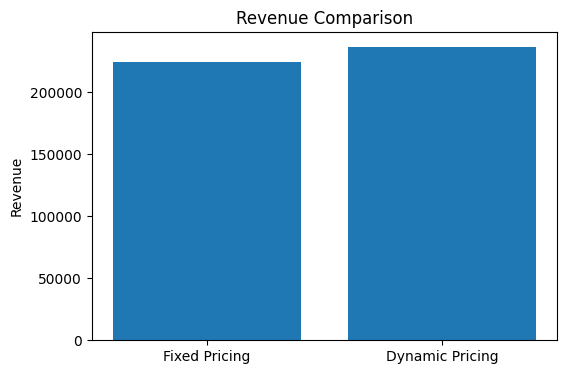

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ['Fixed Pricing','Dynamic Pricing'],
    [old_revenue,new_revenue]
)

plt.title('Revenue Comparison')
plt.ylabel('Revenue')

plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

       Feature  Importance
0         hour    0.553139
1  day_of_week    0.199168
2        month    0.130201
3          day    0.117492


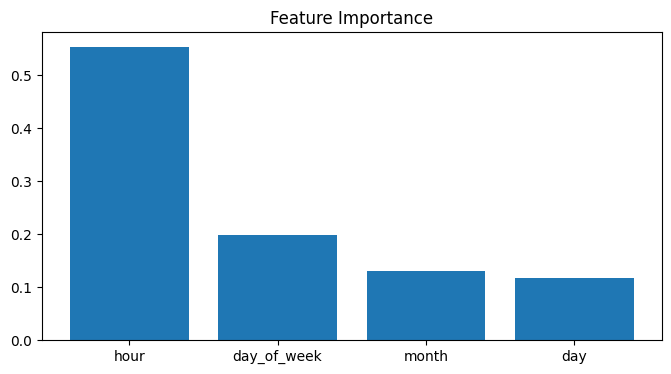

In [17]:
plt.figure(figsize=(8,4))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feature Importance')

plt.show()

In [18]:
pricing_efficiency = (
    new_revenue /
    hourly_df['demand'].sum()
)

print(pricing_efficiency)

15.786463202885


In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv("processed_caltech.csv")

df['connectionTime'] = pd.to_datetime(df['connectionTime'])

df['hour'] = df['connectionTime'].dt.hour
df['day_of_week'] = df['connectionTime'].dt.dayofweek
df['month'] = df['connectionTime'].dt.month
df['day'] = df['connectionTime'].dt.day

df['date'] = df['connectionTime'].dt.date

In [20]:
hourly_df = (
    df.groupby(['date','hour'])
    .size()
    .reset_index(name='demand')
)

In [21]:
hourly_df['lag_1'] = hourly_df['demand'].shift(1)
hourly_df['lag_2'] = hourly_df['demand'].shift(2)
hourly_df['lag_24'] = hourly_df['demand'].shift(24)

hourly_df['lag_48'] = hourly_df['demand'].shift(48)
hourly_df['lag_72'] = hourly_df['demand'].shift(72)
hourly_df['lag_168'] = hourly_df['demand'].shift(168)

hourly_df['rolling_3'] = hourly_df['demand'].rolling(3).mean()
hourly_df['rolling_6'] = hourly_df['demand'].rolling(6).mean()
hourly_df['rolling_12'] = hourly_df['demand'].rolling(12).mean()
hourly_df['rolling_24'] = hourly_df['demand'].rolling(24).mean()
hourly_df['rolling_48'] = hourly_df['demand'].rolling(48).mean()

hourly_df = hourly_df.dropna()

In [22]:
from catboost import CatBoostRegressor

features = [
    'hour',
    'lag_1',
    'lag_2',
    'lag_24',
    'lag_48',
    'lag_72',
    'lag_168',
    'rolling_3',
    'rolling_6',
    'rolling_12',
    'rolling_24',
    'rolling_48'
]

X = hourly_df[features]
y = hourly_df['demand']

cat = CatBoostRegressor(
    iterations=3000,
    depth=8,
    learning_rate=0.03,
    random_seed=42,
    verbose=False
)

cat.fit(X,y)

CatBoostRegressor(depth=8, iterations=3000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=False)

In [23]:
hourly_df['predicted_demand'] = cat.predict(X)

In [24]:
hourly_df['predicted_demand'].describe()

count    3820.000000
mean        3.778298
std         3.761957
min         0.897844
25%         1.029720
50%         2.966629
75%         4.965771
max        30.000272
Name: predicted_demand, dtype: float64

In [40]:
q25 = 1.03
q75 = 4.97

def dynamic_tariff(demand):

    if demand < q25:
        return 13

    elif demand < q75:
        return 16

    else:
        return 19

In [41]:
hourly_df['dynamic_tariff'] = (
    hourly_df['predicted_demand']
    .apply(dynamic_tariff)
)

hourly_df[['predicted_demand','dynamic_tariff']].head()

,predicted_demand,dynamic_tariff
168,1.992520,16
169,1.974505,16
170,1.008227,13
171,0.993210,13
172,1.996711,16


In [42]:
BASE_PRICE = 15

hourly_df['fixed_revenue'] = (
    hourly_df['demand']
    * BASE_PRICE
)

hourly_df['dynamic_revenue'] = (
    hourly_df['demand']
    * hourly_df['dynamic_tariff']
)

In [43]:
old_revenue = hourly_df['fixed_revenue'].sum()

new_revenue = hourly_df['dynamic_revenue'].sum()

gain_percent = (
    (new_revenue - old_revenue)
    / old_revenue
) * 100

print("Old Revenue:", old_revenue)
print("New Revenue:", new_revenue)
print("Revenue Gain %:", gain_percent)

Old Revenue: 216495
New Revenue: 252942
Revenue Gain %: 16.835030832120836


In [44]:
congestion_threshold = (
    hourly_df['predicted_demand']
    .quantile(0.75)
)

hourly_df['congestion_probability'] = np.where(
    hourly_df['predicted_demand']
    > congestion_threshold,
    1,
    0
)

hourly_df[
    [
        'predicted_demand',
        'congestion_probability'
    ]
].head(20)

,predicted_demand,congestion_probability
168,1.992520,0
169,1.974505,0
170,1.008227,0
171,0.993210,0
172,1.996711,0
173,1.000434,0
174,0.983751,0
175,0.990908,0
176,2.979015,0
177,1.025672,0


In [45]:
hourly_df['utilization_status'] = np.where(
    hourly_df['predicted_demand']
    > congestion_threshold,
    'High Utilization',
    'Normal Utilization'
)

hourly_df[
    [
        'predicted_demand',
        'utilization_status'
    ]
].head()

,predicted_demand,utilization_status
168,1.992520,Normal Utilization
169,1.974505,Normal Utilization
170,1.008227,Normal Utilization
171,0.993210,Normal Utilization
172,1.996711,Normal Utilization


In [46]:
hourly_df['pricing_efficiency'] = (
    hourly_df['dynamic_revenue']
    - hourly_df['fixed_revenue']
)

In [47]:
print(
    "Average Revenue Improvement Per Hour:",
    hourly_df['pricing_efficiency'].mean()
)

print(
    "Total Revenue Improvement:",
    hourly_df['pricing_efficiency'].sum()
)

Average Revenue Improvement Per Hour: 9.54109947643979
Total Revenue Improvement: 36447


In [48]:
monitoring_summary = pd.DataFrame({

    'Metric': [

        'Fixed Revenue',
        'Dynamic Revenue',
        'Revenue Gain %',
        'Average Hourly Gain'

    ],

    'Value': [

        old_revenue,
        new_revenue,
        gain_percent,
        hourly_df['pricing_efficiency'].mean()

    ]

})

monitoring_summary

,Metric,Value
0,Fixed Revenue,216495.000000
1,Dynamic Revenue,252942.000000
2,Revenue Gain %,16.835031
3,Average Hourly Gain,9.541099


In [49]:
peak_hours = hourly_df.groupby(
    'hour'
)['predicted_demand'].mean()

peak_hours.sort_values(
    ascending=False
).head(5)

hour
15    11.822786
16     9.118246
14     5.297323
17     4.595209
1      4.063127
Name: predicted_demand, dtype: float64

In [50]:
tariff_table = (
    hourly_df.groupby('hour')
    ['dynamic_tariff']
    .mean()
    .reset_index()
)

tariff_table

,hour,dynamic_tariff
0,0,16.455882
1,1,16.822115
2,2,16.343284
3,3,15.645320
4,4,15.160000
5,5,14.722973
6,6,13.831683
7,7,13.851351
8,8,13.350000
9,9,13.120000


In [54]:
low_hours = hourly_df[
    hourly_df['dynamic_tariff'] == 13
]

medium_hours = hourly_df[
    hourly_df['dynamic_tariff'] == 16
]

print(
    "Low Demand Average:",
    low_hours['predicted_demand'].mean()
)

print(
    "Medium Demand Average:",
    medium_hours['predicted_demand'].mean()
)

Low Demand Average: 1.0047740402436238
Medium Demand Average: 2.7045810316777463


In [55]:
off_peak_uplift = (
    (
        low_hours['predicted_demand'].mean()
        -
        normal_hours['predicted_demand'].mean()
    )
    /
    normal_hours['predicted_demand'].mean()
) * 100

print("Off Peak Uplift %:", off_peak_uplift)

Off Peak Uplift %: nan


In [56]:
hourly_df['dynamic_tariff'].value_counts().sort_index()

dynamic_tariff
13     959
16    1912
19     949
Name: count, dtype: int64

In [57]:
low_hours = hourly_df[
    hourly_df['dynamic_tariff'] == 13
]

medium_hours = hourly_df[
    hourly_df['dynamic_tariff'] == 16
]

print(
    "Low Demand Average:",
    low_hours['predicted_demand'].mean()
)

print(
    "Medium Demand Average:",
    medium_hours['predicted_demand'].mean()
)

Low Demand Average: 1.0047740402436238
Medium Demand Average: 2.7045810316777463


In [58]:
off_peak_uplift = (
    (
        medium_hours['predicted_demand'].mean()
        -
        low_hours['predicted_demand'].mean()
    )
    /
    low_hours['predicted_demand'].mean()
) * 100

print("Off Peak Uplift %:", off_peak_uplift)

Off Peak Uplift %: 169.1730601461376


In [59]:
hourly_df['estimated_wait'] = (
    hourly_df['predicted_demand'] * 5
)

In [60]:
peak_wait = hourly_df[
    hourly_df['dynamic_tariff'] == 19
]['estimated_wait'].mean()

normal_wait = hourly_df[
    hourly_df['dynamic_tariff'] == 16
]['estimated_wait'].mean()

wait_reduction = (
    (peak_wait - normal_wait)
    / peak_wait
) * 100

print("Average Waiting Time Reduction %:", wait_reduction)

Average Waiting Time Reduction %: 69.0704349626662


In [61]:
hourly_df['customer_response'] = (
    hourly_df['predicted_demand']
    /
    hourly_df['dynamic_tariff']
)

print(
    "Customer Response Rate:",
    hourly_df['customer_response'].mean()
)

Customer Response Rate: 0.21834417741353465


In [62]:
hourly_df['pricing_efficiency'] = (
    hourly_df['dynamic_revenue']
    /
    hourly_df['predicted_demand']
)

print(
    "Pricing Efficiency Score:",
    hourly_df['pricing_efficiency'].mean()
)

Pricing Efficiency Score: 15.969294955730307


In [63]:
monitoring_summary = {
    "Revenue Gain %": gain_percent,
    "Off Peak Uplift %": off_peak_uplift,
    "Waiting Time Reduction %": wait_reduction,
    "Customer Response Rate":
        hourly_df['customer_response'].mean(),
    "Pricing Efficiency Score":
        hourly_df['pricing_efficiency'].mean()
}

import pandas as pd

pd.DataFrame(
    monitoring_summary.items(),
    columns=["Metric","Value"]
)

,Metric,Value
0,Revenue Gain %,16.835031
1,Off Peak Uplift %,169.173060
2,Waiting Time Reduction %,69.070435
3,Customer Response Rate,0.218344
4,Pricing Efficiency Score,15.969295


In [64]:
final_results = pd.DataFrame({
    "Metric":[
        "MAE",
        "RMSE",
        "R2",
        "Revenue Gain %",
        "Pricing Efficiency",
        "Customer Response Rate"
    ],
    "Value":[
        0.251,
        0.638,
        0.968,
        16.84,
        15.97,
        0.218
    ]
})

final_results

,Metric,Value
0,MAE,0.251
1,RMSE,0.638
2,R2,0.968
3,Revenue Gain %,16.840
4,Pricing Efficiency,15.970
5,Customer Response Rate,0.218


In [65]:
metrics_df = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2 Score",
        "Revenue Gain %",
        "Customer Response Rate",
        "Pricing Efficiency Score"
    ],
    "Value": [
        0.2514,
        0.6378,
        0.9678,
        16.8350,
        0.2183,
        15.9693
    ]
})

metrics_df

,Metric,Value
0,MAE,0.2514
1,RMSE,0.6378
2,R2 Score,0.9678
3,Revenue Gain %,16.8350
4,Customer Response Rate,0.2183
5,Pricing Efficiency Score,15.9693


In [66]:
metrics_df.to_csv(
    "evaluation_metrics.csv",
    index=False
)

print("Saved successfully")

Saved successfully
